# Synthetic tests
#### Here we test persistent homology on simple, academic examples

In [6]:
%load_ext memory_profiler

# Testing basic functions, their embedding and TDA-PH plots

#### Unofficial ploting methods (from tda.py file)

In [ ]:
# # THIS CODE PLOTS IN MY OWN STYLE

# %%memit
# import numpy as np
# import matplotlib.pyplot as plt
# from ripser import ripser
# import sys
# import os

# sys.path.append(os.path.abspath('..'))
# from tda import plot_barcodes, plot_landscapes, takens_embedding

# def analyze_and_plot_signal(t, signal, signal_name, delay):
#     print(f"\n--- Analyzing signal: {signal_name} ---")

#     # --- Plot and save 2D Takens Embedding ---
#     emb_2d = takens_embedding(signal, delay, dimension=2)
#     plt.figure(figsize=(8, 6))
#     plt.plot(emb_2d[:, 0], emb_2d[:, 1], marker='o', markersize=3, linestyle='-', alpha=0.7)
#     plt.title(f'{signal_name} - 2D Takens Embedding')
#     plt.xlabel('x(t)')
#     plt.ylabel(f'x(t + {delay})')
#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig(f'plots/periodicFunctions/{signal_name}_embedding_2D.png')
#     plt.close()
#     print(f"Saved: {signal_name}_embedding_2D.png")

#     # --- Plot and save 3D Takens Embedding ---
#     emb_3d = takens_embedding(signal, delay, dimension=3)
#     fig = plt.figure(figsize=(8, 6))
#     ax = fig.add_subplot(111, projection='3d')
#     ax.plot(emb_3d[:, 0], emb_3d[:, 1], emb_3d[:, 2], marker='o', markersize=3, linestyle='-', alpha=0.7)
#     ax.set_title(f'{signal_name} - 3D Takens Embedding')
#     ax.set_xlabel('x(t)')
#     ax.set_ylabel(f'x(t + {delay})')
#     ax.set_zlabel(f'x(t + 2*{delay})')
#     plt.tight_layout()
#     plt.savefig(f'plots/periodicFunctions/{signal_name}_embedding_3D.png')
#     plt.close()
#     print(f"Saved: {signal_name}_embedding_3D.png")

#     # --- Compute Persistence and Plot TDA Visualizations ---
#     dimensions_to_analyze = [2, 3, 4, 10]

#     for n in dimensions_to_analyze:
#         embedded_points = takens_embedding(signal, delay=delay, dimension=n)

#         # Compute homologies (maxdim=2 => H0, H1, H2)
#         res = ripser(embedded_points, maxdim=2)
#         dgms = res['dgms']

#         # --- Plot and save Barcodes ---
#         fig, ax = plt.subplots(figsize=(10, 5))
#         barcode_title = f'{signal_name} - Persistence Barcodes (Embedding Dim {n})'
        
#         plot_barcodes(dgms, ax, barcode_title)
        
#         plt.tight_layout()
#         plt.savefig(f'plots/periodicFunctions/{signal_name}_barcodes_dim{n}.png')
#         plt.close(fig)
#         print(f"Saved: {signal_name}_barcodes_dim{n}.png")

#         # --- Plot and save Landscapes ---
#         fig, ax = plt.subplots(figsize=(10, 5))
#         landscape_title = f'{signal_name} - Persistence Landscapes (Embedding Dim {n})'
        
#         plot_landscapes(dgms, ax, landscape_title)
        
#         plt.tight_layout()
#         plt.savefig(f'plots/periodicFunctions/{signal_name}_landscapes_dim{n}.png')
#         plt.close(fig)
#         print(f"Saved: {signal_name}_landscapes_dim{n}.png")

# # ==========================================
# # --- MAIN EXECUTION ---
# # ==========================================

# # Signal parameters
# points_per_period = 100
# # 4 cycles
# t = np.linspace(0, 4 * 2 * np.pi, 4 * points_per_period)

# # Delay (tau) set to 1/4 of the period (25 samples)
# tau = int(points_per_period / 4)

# # TEST SIGNALS
# SineWave = np.sin(t)
# analyze_and_plot_signal(t, SineWave, "SineWave", delay=tau)

# CosPlusT = np.cos(t) + t
# analyze_and_plot_signal(t, CosPlusT, "CosPlusT", delay=tau)

# CosTimesT = np.cos(t) * t
# analyze_and_plot_signal(t, CosTimesT, "CosTimesT", delay=tau)

# CosTimesTPlusT = np.cos(t) * t + t
# analyze_and_plot_signal(t, CosTimesTPlusT, "CosTimesTPlusT", delay=tau)

# mix = np.cos(7 * t) + t + np.sin(3 * t)
# analyze_and_plot_signal(t, mix, "MixedSignal", delay=tau)

# twoSines = np.sin(t) + np.sin(np.sqrt(2) * t)
# analyze_and_plot_signal(t, twoSines, "TwoSines", delay=tau)

# SineCosine = np.sin(t) * np.cos(t)
# analyze_and_plot_signal(t, SineCosine, "SineCosine", delay=tau)


### Official plotting methods 

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
from persim.landscapes import PersLandscapeApprox, plot_landscape_simple
from gtda.time_series import TakensEmbedding
import gudhi
from gudhi.representations import BettiCurve

In [4]:
def analyze_and_plot_signal(t, signal, signal_name, delay):
    print(f"\n--- Analyzing signal: {signal_name} ---")
    
    os.makedirs('plots/periodicFunctions2', exist_ok=True)
    os.makedirs(f'plots/periodicFunctions2/{signal_name}', exist_ok=True)

    # Giotto-TDA (Takens) expects 2D arrays for time series (n_series, n_samples).
    # Since we only have one signal, we reshape it:
    signal_reshaped = signal.reshape(1, -1)

    # ==========================================
    # 1. 2D Takens Embedding (Giotto-TDA)
    # ==========================================
    embedder_2d = TakensEmbedding(time_delay=delay, dimension=2)
    # fit_transform returns a 3D array, we take index [0] since there is only 1 series
    emb_2d = embedder_2d.fit_transform(signal_reshaped)[0] 
    
    plt.figure(figsize=(8, 6))
    plt.plot(emb_2d[:, 0], emb_2d[:, 1], marker='o', markersize=3, linestyle='-', alpha=0.7)
    plt.title(f'{signal_name} - 2D Takens Embedding')
    plt.xlabel('x(t)')
    plt.ylabel(f'x(t + {delay})')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'plots/periodicFunctions2/{signal_name}/{signal_name}_embedding_2D.png')
    plt.close()

    # ==========================================
    # 2. 3D Takens Embedding (Giotto-TDA)
    # ==========================================
    embedder_3d = TakensEmbedding(time_delay=delay, dimension=3)
    emb_3d = embedder_3d.fit_transform(signal_reshaped)[0]
    
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(emb_3d[:, 0], emb_3d[:, 1], emb_3d[:, 2], marker='o', markersize=3, linestyle='-', alpha=0.7)
    ax.set_title(f'{signal_name} - 3D Takens Embedding')
    ax.set_xlabel('x(t)')
    ax.set_ylabel(f'x(t + {delay})')
    ax.set_zlabel(f'x(t + 2*{delay})')
    plt.tight_layout()
    plt.savefig(f'plots/periodicFunctions2/{signal_name}/{signal_name}_embedding_3D.png')
    plt.close()
    
    # ==========================================
    # 3. Topological Analysis 
    # ==========================================
    dimensions_to_analyze = [2, 3, 4, 10]

    for n in dimensions_to_analyze:
        embedder_n = TakensEmbedding(time_delay=delay, dimension=n)
        embedded_points = embedder_n.fit_transform(signal_reshaped)[0]

        # Compute persistent homology (up to H2)
        res = ripser(embedded_points, maxdim=2)
        dgms = res['dgms']

        fig, ax = plt.subplots(figsize=(10, 5))
        
        # Ripser returns a list of arrays. GUDHI expects a list of tuples: (dimension, (birth, death))
        # Convert Ripser data format to GUDHI format
        gudhi_format = [(dim, tuple(pt)) for dim, dgm in enumerate(dgms) for pt in dgm]
        
        # Call GUDHI function to plot barcodes
        gudhi.plot_persistence_barcode(gudhi_format, axes=ax)
        ax.set_title(f'{signal_name} - Persistence Barcodes (Embedding Dim {n})')
        plt.tight_layout()
        plt.savefig(f'plots/periodicFunctions2/{signal_name}/{signal_name}_barcodes_dim{n}.png')
        plt.close(fig)

        # --- Persistence Diagrams (Persim) ---
        fig, ax = plt.subplots(figsize=(8, 6))
        plot_diagrams(dgms, ax=ax, title=f'{signal_name} - Persistence Diagram (Dim {n})')
        plt.tight_layout()
        plt.savefig(f'plots/periodicFunctions2/{signal_name}/{signal_name}_diagrams_dim{n}.png')
        plt.close(fig)

        # --- Persistence Landscapes (Persim) ---
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'{signal_name} - Persistence Landscapes (Embedding Dim {n})', fontsize=14)
        
        for idx, hom_deg in enumerate([1, 2]):
            # 1. Ensure the homology dimension was actually computed by ripser
            if hom_deg < len(dgms):
                dgm_for_deg = dgms[hom_deg]
                
                # 2. Filter out points at infinity (landscapes do not handle them well)
                finite_dgm = dgm_for_deg[dgm_for_deg[:, 1] != np.inf]
                
                # 3. Check if there are any finite features left to plot
                if len(finite_dgm) > 0:
                    pla = PersLandscapeApprox(dgms=[finite_dgm], hom_deg=0)
                    plot_landscape_simple(
                        pla, 
                        ax=axes[idx], 
                        alpha=0.5,
                        title=f'$H_{hom_deg}$ Landscape', 
                        depth_range=range(4) # Limits plot to the top 4 lambda functions
                    )                
                else:
                    axes[idx].set_title(f'$H_{hom_deg}$ - No finite features')
                    axes[idx].axis('off')
            else:
                axes[idx].set_title(f'$H_{hom_deg}$ - Dimension not computed')
                axes[idx].axis('off')
                
        plt.tight_layout()
        plt.savefig(f'plots/periodicFunctions2/{signal_name}/{signal_name}_landscapes_dim{n}.png')
        plt.close(fig)

        # --- Betti Curves (GUDHI) ---
        fig_bc, axes_bc = plt.subplots(1, 2, figsize=(14, 5))
        fig_bc.suptitle(f'{signal_name} - Betti Curves (Embedding Dim {n})', fontsize=14)
        
        for idx, hom_deg in enumerate([1, 2]):
            if hom_deg < len(dgms):
                dgm_for_deg = dgms[hom_deg]
                finite_dgm = dgm_for_deg[dgm_for_deg[:, 1] != np.inf]
                
                if len(finite_dgm) > 0:
                    min_b, max_d = np.min(finite_dgm[:, 0]), np.max(finite_dgm[:, 1])
                    
                    # GUDHI Transformer (computes the Betti Curve vector)
                    bc_transformer = BettiCurve(resolution=500, sample_range=[min_b, max_d])
                    
                    # fit_transform expects a list of diagrams, so we pass [finite_dgm]
                    # and extract the first calculated vector [0]
                    betti_vals = bc_transformer.fit_transform([finite_dgm])[0]
                    t_vals = np.linspace(min_b, max_d, 500)
                    
                    # Plot the resulting vector using a step function
                    # axes_bc[idx].step(t_vals, betti_vals, where='post', color='#9467bd', linewidth=2)
                    # axes_bc[idx].fill_between(t_vals, betti_vals, step='post', alpha=0.3, color='#9467bd')
                    axes_bc[idx].plot(t_vals, betti_vals, linewidth=2, label=f'$H_{hom_deg}$')
                    axes_bc[idx].legend() # Żeby pokazać legendę jak na Twoim screenie
                    axes_bc[idx].set_title(f'$H_{hom_deg}$ Betti Curve')
                    axes_bc[idx].set_xlabel("Filtration Parameter ($\epsilon$)")
                    axes_bc[idx].set_ylabel("Betti Number")
                else:
                    axes_bc[idx].set_title(f'$H_{hom_deg}$ - No finite features')
                    axes_bc[idx].axis('off')
            else:
                axes_bc[idx].set_title(f'$H_{hom_deg}$ - Dimension not computed')
                axes_bc[idx].axis('off')
                
        plt.tight_layout()
        plt.savefig(f'plots/periodicFunctions2/{signal_name}/{signal_name}_betti_dim{n}.png')
        plt.close(fig_bc)
        
        print(f"Saved all TDA plots for {signal_name} in Dim {n}.")


In [ ]:

# ==========================================
# --- MAIN EXECUTION ---
# ==========================================

points_per_period = 100
t = np.linspace(0, 4 * 2 * np.pi, 4 * points_per_period)
tau = int(points_per_period / 4)

# Dictionary of signals to analyze
signals = {
    "SineWave": np.sin(t),
    "CosPlusT": np.cos(t) + t,
    "CosTimesT": np.cos(t) * t,
    "CosTimesTPlusT": np.cos(t) * t + t,
    "MixedSignal": np.cos(7 * t) + t + np.sin(3 * t),
    "TwoSines": np.sin(t) + np.sin(np.sqrt(2) * t),
    "SineCosine": np.sin(t) * np.cos(t)
}

# Execution loop
for name, sig in signals.items():
    analyze_and_plot_signal(t, sig, name, delay=tau)


--- Analyzing signal: SineWave ---


/home/bamichal/miniforge3/envs/tda_stable/lib/python3.11/site-packages/gudhi/persistence_graphical_tools.py:150: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


Saved all TDA plots for SineWave in Dim 2.
Saved all TDA plots for SineWave in Dim 3.
Saved all TDA plots for SineWave in Dim 4.
Saved all TDA plots for SineWave in Dim 10.

--- Analyzing signal: CosPlusT ---
Saved all TDA plots for CosPlusT in Dim 2.
Saved all TDA plots for CosPlusT in Dim 3.
Saved all TDA plots for CosPlusT in Dim 4.
Saved all TDA plots for CosPlusT in Dim 10.

--- Analyzing signal: CosTimesT ---
Saved all TDA plots for CosTimesT in Dim 2.
Saved all TDA plots for CosTimesT in Dim 3.
Saved all TDA plots for CosTimesT in Dim 4.
Saved all TDA plots for CosTimesT in Dim 10.

--- Analyzing signal: CosTimesTPlusT ---
Saved all TDA plots for CosTimesTPlusT in Dim 2.
Saved all TDA plots for CosTimesTPlusT in Dim 3.
Saved all TDA plots for CosTimesTPlusT in Dim 4.
Saved all TDA plots for CosTimesTPlusT in Dim 10.

--- Analyzing signal: MixedSignal ---
Saved all TDA plots for MixedSignal in Dim 2.
Saved all TDA plots for MixedSignal in Dim 3.
Saved all TDA plots for MixedSigna

#### Addding noise

In [2]:
# points_per_period = 100
# t = np.linspace(0, 4 * 2 * np.pi, 4 * points_per_period)
# tau = int(points_per_period / 4)

# noise_level = 0.2
# noise_array = np.random.normal(loc=0.0, scale=noise_level, size=len(t))

# signals = {
#     "SineWave": np.sin(t),
#     "SineWave_Noisy": np.sin(t) + noise_array,
    
#     "CosTimesTPlusT": np.cos(t) * t + t,
#     "CosTimesTPlusT_Noisy": (np.cos(t) * t + t) + noise_array * (t/5) # Noise grows with time
# }

# for name, sig in signals.items():
#     analyze_and_plot_signal(t, sig, name, delay=tau)

In [6]:
points_per_period = 100
t = np.linspace(0, 4 * 2 * np.pi, 4 * points_per_period)
tau = int(points_per_period / 4)

noise_level_continuous = 0.1
gaussian_noise = np.random.normal(loc=0.0, scale=noise_level_continuous, size=len(t))


jump_probability = 0.03 
jump_amplitudes = np.random.normal(loc=0.0, scale=noise_level_continuous * 10, size=len(t)) 
jumps = np.random.binomial(n=1, p=jump_probability, size=len(t))
jump_noise = jumps * jump_amplitudes

signals = {
    "SineWave": np.sin(t),
    "CosTimesTPlusT": np.cos(t) * t + t,
    
    "SineWave_Gaussian": np.sin(t) + gaussian_noise,
    "CosTimesTPlusT_Gaussian": (np.cos(t) * t + t) + gaussian_noise * (t/5),
    
    "SineWave_Jumps": np.sin(t) + jump_noise,
    "CosTimesTPlusT_Jumps": (np.cos(t) * t + t) + jump_noise * (t/5)
}

for name, sig in signals.items():
    analyze_and_plot_signal(t, sig, name, delay=tau)


--- Analyzing signal: SineWave ---
Saved all TDA plots for SineWave in Dim 2.
Saved all TDA plots for SineWave in Dim 3.
Saved all TDA plots for SineWave in Dim 4.
Saved all TDA plots for SineWave in Dim 10.

--- Analyzing signal: CosTimesTPlusT ---
Saved all TDA plots for CosTimesTPlusT in Dim 2.
Saved all TDA plots for CosTimesTPlusT in Dim 3.
Saved all TDA plots for CosTimesTPlusT in Dim 4.
Saved all TDA plots for CosTimesTPlusT in Dim 10.

--- Analyzing signal: SineWave_Gaussian ---
Saved all TDA plots for SineWave_Gaussian in Dim 2.
Saved all TDA plots for SineWave_Gaussian in Dim 3.
Saved all TDA plots for SineWave_Gaussian in Dim 4.
Saved all TDA plots for SineWave_Gaussian in Dim 10.

--- Analyzing signal: CosTimesTPlusT_Gaussian ---
Saved all TDA plots for CosTimesTPlusT_Gaussian in Dim 2.
Saved all TDA plots for CosTimesTPlusT_Gaussian in Dim 3.
Saved all TDA plots for CosTimesTPlusT_Gaussian in Dim 4.
Saved all TDA plots for CosTimesTPlusT_Gaussian in Dim 10.

--- Analyzing

### Try to recover true persistence with DTM

Filtered 7 outliers in R^3 space.


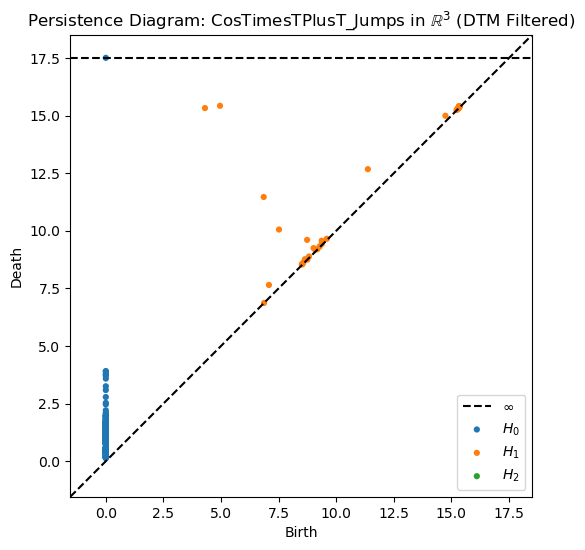

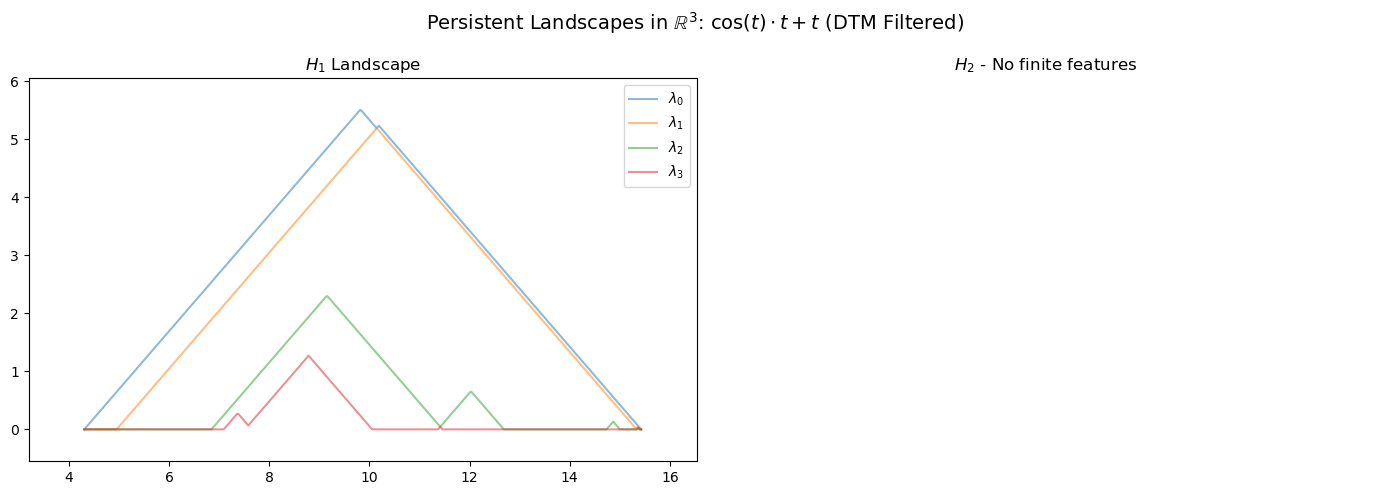

In [26]:
from sklearn.neighbors import NearestNeighbors

# ==========================================
# STEP 1: DTM-based Outlier Filtration in R^3
# ==========================================

embedder = TakensEmbedding(time_delay=tau, dimension=3)
raw_signal = signals["CosTimesTPlusT_Jumps"].reshape(1, -1)
X_jumps_3d = embedder.fit_transform(raw_signal)[0] 

k_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors, algorithm='ball_tree').fit(X_jumps_3d)
distances, _ = nbrs.kneighbors(X_jumps_3d)
dtm_vals_3d = np.sqrt(np.mean(distances**2, axis=1))

threshold_3d = np.percentile(dtm_vals_3d, 98)
mask_clean_3d = dtm_vals_3d <= threshold_3d
X_clean_3d = X_jumps_3d[mask_clean_3d]

print(f"Filtered {len(X_jumps_3d) - len(X_clean_3d)} outliers in R^3 space.")


# ==========================================
# STEP 2: TDA & Landscapes (H1 and H2)
# ==========================================

result_dtm_cleaned_3d = ripser(X_clean_3d, maxdim=2)
diagrams_dtm_cleaned_3d = result_dtm_cleaned_3d['dgms']
plt.figure(figsize=(6, 6))
plot_diagrams(diagrams_dtm_cleaned_3d, title="Persistence Diagram: CosTimesTPlusT_Jumps in $\mathbb{R}^3$ (DTM Filtered)")
plt.show()

finite_diagrams = []
for dgm in diagrams_dtm_cleaned_3d:
    if len(dgm) > 0:
        finite_diagrams.append(dgm[dgm[:, 1] != np.inf])
    else:
        finite_diagrams.append(dgm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target_homologies = [1, 2] 

for i, hom_deg in enumerate(target_homologies):
    if hom_deg < len(finite_diagrams) and len(finite_diagrams[hom_deg]) > 0:
        pla = PersLandscapeApprox(dgms=finite_diagrams, hom_deg=hom_deg)
        plot_landscape_simple(
            pla, 
            ax=axes[i], 
            alpha=0.5,
            title=f'$H_{hom_deg}$ Landscape', 
            depth_range=range(4) 
        )
    else:
        axes[i].set_title(f'$H_{{{hom_deg}}}$ - No finite features')
        axes[i].axis('off')
        
plt.suptitle("Persistent Landscapes in $\mathbb{R}^3$: $\cos(t) \cdot t + t$ (DTM Filtered)", fontsize=14)
plt.tight_layout()
plt.savefig('plots/periodicFunctions2/CosTimesTPlusT_Jumps/CosTimesTPlusT_Jumps_landscapes_DTM.png', bbox_inches='tight')
plt.show()

# Finding optimal time delay

#### Naive AMI (not smoothed)

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from gtda.time_series import TakensEmbedding
from sklearn.metrics import mutual_info_score
from scipy.signal import argrelmin

os.makedirs('plots/delay_effect', exist_ok=True)

# ==========================================
# 1. GENERATE SIGNAL
# ==========================================
# Generate a simple sine wave (1000 samples per period, 3 periods)
points_per_period = 1000
t = np.linspace(0, 3 * 2 * np.pi, 3 * points_per_period)
signal = np.sin(t)
signal_reshaped = signal.reshape(1, -1)

# ==========================================
# 2. MANUAL DELAY COMPARISON (Original part)
# ==========================================
# Select three delay variants
delays_to_test = [
    2,   # Too small (barely unfolded)
    250,  # Optimal (1/4 period - perfect circle)
    500   # Too large (1/2 period - anti-diagonal)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Effect of Time Delay ($\\tau$) on 2D Takens Embedding", fontsize=16)

for idx, delay in enumerate(delays_to_test):
    # Compute the embedding
    embedder = TakensEmbedding(time_delay=delay, dimension=2)
    emb = embedder.fit_transform(signal_reshaped)[0]
    
    # Plot the embedding
    ax = axes[idx]
    ax.plot(emb[:, 0], emb[:, 1], marker='o', markersize=3, linestyle='-', alpha=0.7)
    ax.set_title(f'Delay $\\tau$ = {delay}')
    ax.set_xlabel('x(t)')
    ax.set_ylabel(f'x(t + {delay})')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Maintain equal aspect ratio to show the true geometric shape
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])

plt.tight_layout()
plt.savefig('plots/delay_effect/Takens_Delay_Comparison.png', dpi=300)
plt.close(fig)
print("Saved: Takens_Delay_Comparison.png")


# ==========================================
# 3. AVERAGE MUTUAL INFORMATION (AMI) CALCULATION
# ==========================================
def compute_ami(sig, delay, bins=20):
    """
    Computes the Average Mutual Information for a given time delay 
    using 2D histogram-based probability density estimation.
    """
    y1 = sig[:-delay]
    y2 = sig[delay:]
    
    # Compute the 2D contingency table (joint probability distribution)
    c_xy = np.histogram2d(y1, y2, bins)[0]
    
    # Calculate Mutual Information from the contingency table
    return mutual_info_score(None, None, contingency=c_xy)

max_delay_to_test = 500
delays = np.arange(1, max_delay_to_test + 1)
ami_values = [compute_ami(signal, d, bins=20) for d in delays]

# Identify the first local minimum
local_minima = argrelmin(np.array(ami_values))[0]

if len(local_minima) > 0:
    optimal_idx = local_minima[0]
    # Explicit cast to native Python int to comply with gtda type validation
    optimal_delay = int(delays[optimal_idx])
    optimal_ami = ami_values[optimal_idx]
else:
    optimal_delay = 1
    optimal_ami = ami_values[0]

print(f"Optimal Time Delay (First Local Minimum): tau = {optimal_delay}")

# ==========================================
# 4. PLOT AMI CURVE AND OPTIMAL EMBEDDING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Optimal Time Delay Selection via Average Mutual Information", fontsize=16)

# --- Plot 1: AMI Curve ---
ax1.plot(delays, ami_values, color='#1f77b4', linewidth=2, label='AMI Curve')
ax1.axvline(x=optimal_delay, color='#d62728', linestyle='--', linewidth=2, 
            label=f'First Local Minimum ($\\tau$={optimal_delay})')
ax1.plot(optimal_delay, optimal_ami, marker='o', markersize=8, color='#d62728')

ax1.set_title("Average Mutual Information vs. Time Delay")
ax1.set_xlabel("Time Delay ($\\tau$)")
ax1.set_ylabel("AMI (bits)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Takens Embedding with Optimal Delay ---
optimal_embedder = TakensEmbedding(time_delay=optimal_delay, dimension=2)
optimal_emb = optimal_embedder.fit_transform(signal_reshaped)[0]

ax2.plot(optimal_emb[:, 0], optimal_emb[:, 1], marker='o', markersize=3, 
         linestyle='-', color='#2ca02c', alpha=0.7)
ax2.set_title(f"2D Takens Embedding (Optimal $\\tau$ = {optimal_delay})")
ax2.set_xlabel('x(t)')
ax2.set_ylabel(f'x(t + {optimal_delay})')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlim([-1.2, 1.2])
ax2.set_ylim([-1.2, 1.2])

plt.tight_layout()
plt.savefig('plots/delay_effect/Optimal_AMI_Embedding.png', dpi=300)
plt.close(fig)

Saved: Takens_Delay_Comparison.png
Optimal Time Delay (First Local Minimum): tau = 13


#### Smoothed AMI

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from gtda.time_series import TakensEmbedding
from sklearn.metrics import mutual_info_score
from scipy.signal import argrelmin
from scipy.ndimage import gaussian_filter1d

os.makedirs('plots/delay_effect', exist_ok=True)

# ==========================================
# 1. GENERATE SIGNAL
# ==========================================
# Generate a simple sine wave (1000 samples per period, 3 periods)
points_per_period = 1000
t = np.linspace(0, 3 * 2 * np.pi, 3 * points_per_period)
signal = np.sin(t)
signal_reshaped = signal.reshape(1, -1)

# ==========================================
# 2. MANUAL DELAY COMPARISON (Original part)
# ==========================================
# Select three delay variants
delays_to_test = [
    2,   # Too small (barely unfolded)
    250,  # Optimal (1/4 period - perfect circle)
    500   # Too large (1/2 period - anti-diagonal)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Effect of Time Delay ($\\tau$) on 2D Takens Embedding", fontsize=16)

for idx, delay in enumerate(delays_to_test):
    # Compute the embedding
    embedder = TakensEmbedding(time_delay=delay, dimension=2)
    emb = embedder.fit_transform(signal_reshaped)[0]
    
    # Plot the embedding
    ax = axes[idx]
    ax.plot(emb[:, 0], emb[:, 1], marker='o', markersize=3, linestyle='-', alpha=0.7)
    ax.set_title(f'Delay $\\tau$ = {delay}')
    ax.set_xlabel('x(t)')
    ax.set_ylabel(f'x(t + {delay})')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Maintain equal aspect ratio to show the true geometric shape
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])

plt.tight_layout()
plt.savefig('plots/delay_effect/Takens_Delay_Smoothed_Comparison.png', dpi=300)
plt.close(fig)
print("Saved: Takens_Delay_Smoothed_Comparison.png")


# ==========================================
# 3. AVERAGE MUTUAL INFORMATION (AMI) CALCULATION
# ==========================================
def compute_ami(sig, delay, bins=1000):
    """
    Computes the Average Mutual Information for a given time delay 
    using 2D histogram-based probability density estimation.
    """
    y1 = sig[:-delay]
    y2 = sig[delay:]
    
    # Compute the 2D contingency table (joint probability distribution)
    c_xy = np.histogram2d(y1, y2, bins)[0]
    
    # Calculate Mutual Information from the contingency table
    return mutual_info_score(None, None, contingency=c_xy)

max_delay_to_test = 500
delays = np.arange(1, max_delay_to_test + 1)
ami_values = [compute_ami(signal, d, bins=1000) for d in delays]

# Identify the first local minimum
smoothed_ami = gaussian_filter1d(ami_values, sigma=20)
local_minima = argrelmin(smoothed_ami)[0]

if len(local_minima) > 0:
    optimal_idx = local_minima[0]
    # Explicit cast to native Python int to comply with gtda type validation
    optimal_delay = int(delays[optimal_idx])
    optimal_ami = ami_values[optimal_idx]
else:
    optimal_delay = 1
    optimal_ami = ami_values[0]

print(f"Optimal Time Delay (First Local Minimum): tau = {optimal_delay}")

# ==========================================
# 4. PLOT AMI CURVE AND OPTIMAL EMBEDDING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Optimal Time Delay Selection via Average Mutual Information", fontsize=16)

# --- Plot 1: AMI Curve ---
ax1.plot(delays, ami_values, color='#1f77b4', linewidth=2, label='AMI Curve')
ax1.plot(delays, smoothed_ami, color='#ff7f0e', linewidth=2, label='Smoothed AMI')
ax1.axvline(x=optimal_delay, color='#d62728', linestyle='--', linewidth=2, 
            label=f'First Local Minimum ($\\tau$={optimal_delay})')
ax1.plot(optimal_delay, optimal_ami, marker='o', markersize=8, color='#d62728')

ax1.set_title("Average Mutual Information vs. Time Delay")
ax1.set_xlabel("Time Delay ($\\tau$)")
ax1.set_ylabel("AMI (bits)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Takens Embedding with Optimal Delay ---
optimal_embedder = TakensEmbedding(time_delay=optimal_delay, dimension=2)
optimal_emb = optimal_embedder.fit_transform(signal_reshaped)[0]

ax2.plot(optimal_emb[:, 0], optimal_emb[:, 1], marker='o', markersize=3, 
         linestyle='-', color='#2ca02c', alpha=0.7)
ax2.set_title(f"2D Takens Embedding (Optimal $\\tau$ = {optimal_delay})")
ax2.set_xlabel('x(t)')
ax2.set_ylabel(f'x(t + {optimal_delay})')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlim([-1.2, 1.2])
ax2.set_ylim([-1.2, 1.2])

plt.tight_layout()
plt.savefig('plots/delay_effect/Optimal_AMI_Smoothed_Embedding.png', dpi=300)
plt.close(fig)

Saved: Takens_Delay_Smoothed_Comparison.png
Optimal Time Delay (First Local Minimum): tau = 205


# Finding best params for AMI and its smoothing

### First look at what we have

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from gtda.time_series import TakensEmbedding
from sklearn.metrics import mutual_info_score
from scipy.signal import argrelmin
from scipy.ndimage import gaussian_filter1d

os.makedirs('plots/hyperparameter_study', exist_ok=True)

# ==========================================
# 1. GENERATE HIGH-RESOLUTION SIGNAL
# ==========================================
points_per_period = 1000
t = np.linspace(0, 3 * 2 * np.pi, 3 * points_per_period)
signal = np.sin(t)
signal_reshaped = signal.reshape(1, -1)

max_delay_to_test = 500
delays = np.arange(1, max_delay_to_test + 1)

def compute_ami(sig, delay, bins=20):
    """Computes AMI using 2D histogram binning."""
    y1 = sig[:-delay]
    y2 = sig[delay:]
    c_xy = np.histogram2d(y1, y2, bins)[0]
    return mutual_info_score(None, None, contingency=c_xy)

# ==========================================
# 2. EXPERIMENT 1: THE NAIVE APPROACH (NO SMOOTHING)
# ==========================================
print("Running Experiment 1: Naive Approach...")

# We use 50 bins to intentionally expose the numerical noise
ami_raw = [compute_ami(signal, d, bins=50) for d in delays]

# Find the first local minimum on the RAW, noisy curve
local_minima_raw = argrelmin(np.array(ami_raw))[0]
optimal_delay_raw = int(delays[local_minima_raw[0]]) if len(local_minima_raw) > 0 else 1
optimal_ami_raw = ami_raw[local_minima_raw[0]] if len(local_minima_raw) > 0 else ami_raw[0]

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig1.suptitle("First Minimum in Raw AMI and Suboptimal Embedding", fontsize=16)

# Plot Raw AMI
ax1.plot(delays, ami_raw, color='#1f77b4', linewidth=1.5, label='Raw AMI Curve (bins=50)')
ax1.axvline(x=optimal_delay_raw, color='#d62728', linestyle='--', linewidth=2, 
            label=f'False Local Minimum ($\\tau$={optimal_delay_raw})')
ax1.plot(optimal_delay_raw, optimal_ami_raw, marker='o', markersize=8, color='#d62728')
ax1.set_title("Raw Average Mutual Information vs. Time Delay")
ax1.set_xlabel("Time Delay ($\\tau$)")
ax1.set_ylabel("AMI (bits)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Failed Embedding
embedder_raw = TakensEmbedding(time_delay=optimal_delay_raw, dimension=2)
emb_raw = embedder_raw.fit_transform(signal_reshaped)[0]
ax2.plot(emb_raw[:, 0], emb_raw[:, 1], color='#d62728', linewidth=2, alpha=0.8)
ax2.set_title(f"Suboptimal 2D Takens Embedding ($\\tau$ = {optimal_delay_raw})")
ax2.set_xlabel('x(t)')
ax2.set_ylabel(f'x(t + {optimal_delay_raw})')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlim([-1.2, 1.2])
ax2.set_ylim([-1.2, 1.2])

plt.tight_layout()
plt.savefig('plots/hyperparameter_study/01_Naive_AMI_Failure.png', dpi=300)
plt.close(fig1)

# ==========================================
# 3. EXPERIMENT 2: HYPERPARAMETER SENSITIVITY (BINS & SIGMA)
# ==========================================
print("Running Experiment 2: Hyperparameter Sensitivity...")

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle("Hyperparameter Sensitivity in AMI Computation", fontsize=16)

# --- PANEL A: Effect of Bin Size (No Smoothing) ---
bins_to_test = [10, 50, 100]
colors_bins = ['#2ca02c', '#1f77b4', '#ff7f0e']

for b, color in zip(bins_to_test, colors_bins):
    ami_b = [compute_ami(signal, d, bins=b) for d in delays]
    ax3.plot(delays, ami_b, color=color, linewidth=1.5, alpha=0.8, 
             label=f'Bins = {b}')

ax3.set_title("A) Effect of Histogram Resolution (No Smoothing)")
ax3.set_xlabel("Time Delay ($\\tau$)")
ax3.set_ylabel("AMI (bits)")
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.6)

# --- PANEL B: Effect of Gaussian Smoothing (Fixed Bins=50) ---
# We use the raw AMI with 50 bins from Experiment 1
sigmas_to_test = [2, 20, 100]
colors_sigmas = ['#9467bd', '#d62728', '#8c564b']

ax4.plot(delays, ami_raw, color='gray', linewidth=1, alpha=0.4, label='Raw (bins=50)')

for s, color in zip(sigmas_to_test, colors_sigmas):
    ami_smoothed = gaussian_filter1d(ami_raw, sigma=s)
    
    # Optional: Find minimum for the optimal sigma (e.g., sigma=20)
    if s == 20:
        min_idx = argrelmin(ami_smoothed)[0][0]
        ax4.axvline(x=delays[min_idx], color=color, linestyle=':', 
                    label=f'True Minimum ($\\tau$={delays[min_idx]})')
        
    ax4.plot(delays, ami_smoothed, color=color, linewidth=2, 
             label=f'Gaussian Filter ($\\sigma$ = {s})')

ax4.set_title("B) Effect of Gaussian Smoothing $\\sigma$ (Fixed Bins=50)")
ax4.set_xlabel("Time Delay ($\\tau$)")
ax4.set_ylabel("AMI (bits)")
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('plots/hyperparameter_study/02_Hyperparameters_Bins_Sigma.png', dpi=300)
plt.close(fig2)

print("Saved all hyperparameter study plots!")

Running Experiment 1: Naive Approach...
Running Experiment 2: Hyperparameter Sensitivity...
Saved all hyperparameter study plots!


### Calculating possible combinations of number of bins and sigmas

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from gtda.time_series import TakensEmbedding
from sklearn.metrics import mutual_info_score
from scipy.signal import argrelmin
from scipy.ndimage import gaussian_filter1d

os.makedirs('plots/hyperparameter_study', exist_ok=True)

# ==========================================
# 1. SIGNAL GENERATION (High Res)
# ==========================================
points_per_period = 1000
t = np.linspace(0, 3 * 2 * np.pi, 3 * points_per_period)
signal = np.sin(t)
signal_reshaped = signal.reshape(1, -1)

max_delay = 500
delays = np.arange(1, max_delay + 1)

def compute_ami(sig, delay, bins=20):
    y1 = sig[:-delay]
    y2 = sig[delay:]
    c_xy = np.histogram2d(y1, y2, bins)[0]
    return mutual_info_score(None, None, contingency=c_xy)

# ==========================================
# 2. GRID SEARCH (Parameter Sweep) - HIGH RESOLUTION
# ==========================================
print("Starting high-resolution parameter sweep (20,000 combinations)...")
print("Grab a coffee, this might take a few minutes!")

bins_array = np.arange(1, 1001, 1)
sigmas_array = np.arange(1, 101, 1)

opt_tau_matrix = np.zeros((len(bins_array), len(sigmas_array)))

print("Step 1/2: Precomputing raw AMI for all bin sizes...")
raw_ami_dict = {}
for b in bins_array:
    raw_ami_dict[b] = np.array([compute_ami(signal, d, bins=b) for d in delays])

print("Step 2/2: Applying Gaussian filters and finding minima...")
for i, b in enumerate(bins_array):
    raw_ami = raw_ami_dict[b]
    for j, s in enumerate(sigmas_array):
        smoothed_ami = gaussian_filter1d(raw_ami, sigma=s)
        local_minima = argrelmin(smoothed_ami)[0]
        
        if len(local_minima) > 0:
            opt_tau_matrix[i, j] = delays[local_minima[0]]
        else:
            opt_tau_matrix[i, j] = max_delay  # Assign max_delay if no minima found (or could use np.nan)

print("Grid search completed! Generating plots...")

# ==========================================
# 3. PLOT A: 3D SURFACE PLOT
# ==========================================
B_grid, S_grid = np.meshgrid(bins_array, sigmas_array, indexing='ij')

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(B_grid, S_grid, opt_tau_matrix, cmap=cm.viridis, 
                       linewidth=0, antialiased=True, alpha=0.9)

ax.set_title("Optimal Time Delay ($\\tau$) Landscape\nSensitivity to Histogram Bins and Gaussian Smoothing", fontsize=16)
ax.set_xlabel("Number of Bins")
ax.set_ylabel("Gaussian Filter $\\sigma$")
ax.set_zlabel("Detected Optimal $\\tau$")

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Optimal $\\tau$ Value")
plt.tight_layout()
plt.savefig('plots/hyperparameter_study/03_3D_Parameter_Landscape.png', dpi=300)
plt.close(fig)
print("Saved: 03_3D_Parameter_Landscape.png")

# ==========================================
# 4. PLOT B: REPRESENTATIVE EMBEDDINGS GRID
# ==========================================
# Let's pick 4 representative points from the 3D surface to show the embeddings
# scenarios = [
#     {"bins": 150, "sigma": 1, "title": "High Bins, Low Sigma\n(Trapped by Noise)"},
#     {"bins": 10, "sigma": 50, "title": "Low Bins, High Sigma\n(Oversmoothed & Flattened)"},
#     {"bins": 10, "sigma": 1, "title": "Low Bins, Low Sigma\n(Coarse Artifacts)"},
#     {"bins": 50, "sigma": 20, "title": "Optimal Zone (The Plateau)\n(Robust Unfolding)"}
# ]
scenarios = [
    {"bins": 150, "sigma": 1},
    {"bins": 5, "sigma": 20},
    {"bins": 5, "sigma": 1},
    {"bins": 150, "sigma": 20}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle("2D Takens Embeddings Across Different Hyperparameter Regimes", fontsize=16)
axes = axes.flatten()

for idx, scenario in enumerate(scenarios):
    b = scenario["bins"]
    s = scenario["sigma"]
    
    # Re-fetch the precomputed raw AMI and smooth it
    smoothed_ami = gaussian_filter1d(raw_ami_dict[b], sigma=s)
    local_minima = argrelmin(smoothed_ami)[0]
    tau = int(delays[local_minima[0]]) if len(local_minima) > 0 else 1    
    # Generate Embedding
    embedder = TakensEmbedding(time_delay=tau, dimension=2)
    emb = embedder.fit_transform(signal_reshaped)[0]
    
    # Plot
    ax = axes[idx]
    ax.plot(emb[:, 0], emb[:, 1], color='#1f77b4', linewidth=2, alpha=0.7)
    
    # Highlight the specific parameter values in the title
    # ax.set_title(f'{scenario["title"]}\nbins={b}, $\\sigma$={s} $\\rightarrow$ Detected $\\tau$={tau}')
    ax.set_title(f'bins={b}, $\\sigma$={s} $\\rightarrow$ Detected $\\tau$={tau}')
    ax.set_xlabel('x(t)')
    ax.set_ylabel(f'x(t + {tau})')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])

plt.tight_layout()
plt.savefig('plots/hyperparameter_study/04_Embedding_Grid.png', dpi=300)
plt.close(fig)
print("Saved: 04_Embedding_Grid.png")



Starting high-resolution parameter sweep (20,000 combinations)...
Grab a coffee, this might take a few minutes!
Step 1/2: Precomputing raw AMI for all bin sizes...
Step 2/2: Applying Gaussian filters and finding minima...
Grid search completed! Generating plots...
Saved: 03_3D_Parameter_Landscape.png
Saved: 04_Embedding_Grid.png


### Better visualisations

In [ ]:
# ==========================================
# 5. ALTERNATIVE VISUALIZATIONS (HEATMAP & CROSS-SECTIONS)
# ==========================================
print("Generating Heatmap and Cross-sections...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Hyperparameter Sensitivity: Heatmap and 2D Cross-sections", fontsize=16)

# --- PANEL A: 2D Heatmap (Top-down view of the 3D surface) ---
# We use pcolormesh. Note: Z-matrix must be transposed to match X (bins) and Y (sigmas)
ax_heat = axes[0]
c = ax_heat.pcolormesh(bins_array, sigmas_array, opt_tau_matrix.T, 
                       cmap='viridis', shading='auto', vmin=0, vmax=260)

ax_heat.set_title("A) Heatmap of Optimal $\\tau$")
ax_heat.set_xlabel("Number of Bins")
ax_heat.set_ylabel("Gaussian Filter $\\sigma$")

cbar = fig.colorbar(c, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label("Detected Optimal $\\tau$")

# --- PANEL B: 1D Cross-sections (Slices of the 3D surface) ---
ax_lines = axes[1]

selected_bins = [5, 10, 50, 200, 800]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']

for b_val, color in zip(selected_bins, colors):
    b_idx = np.where(bins_array == b_val)[0][0]
    tau_slice = opt_tau_matrix[b_idx, :]
    ax_lines.plot(sigmas_array, tau_slice, color=color, linewidth=2, alpha=0.8,
                  label=f'Bins = {b_val}')

ax_lines.set_title("B) Sensitivity to Smoothing for Fixed Bin Sizes")
ax_lines.set_xlabel("Gaussian Filter $\\sigma$")
ax_lines.set_ylabel("Detected Optimal $\\tau$")
ax_lines.legend()
ax_lines.grid(True, linestyle='--', alpha=0.6)

ax_lines.set_ylim([0, 260])

plt.tight_layout()
plt.savefig('plots/hyperparameter_study/05_Heatmap_and_Slices.png', dpi=300)
plt.close(fig)
print("Saved: 05_Heatmap_and_Slices.png")

Generating Heatmap and Cross-sections...
Saved: 05_Heatmap_and_Slices.png


### Better visuals + marked theoretical opt. for $\sin t$

In [ ]:
# ==========================================
# 5. ALTERNATIVE VISUALIZATIONS (HEATMAP & CROSS-SECTIONS)
# ==========================================
print("Generating Heatmap and Cross-sections...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Hyperparameter Sensitivity: Heatmap and 2D Cross-sections", fontsize=16)

# --- PANEL A: 2D Heatmap (Top-down view of the 3D surface) ---
ax_heat = axes[0]
c = ax_heat.pcolormesh(bins_array, sigmas_array, opt_tau_matrix.T, 
                       cmap='viridis', shading='auto', vmin=0, vmax=260)

ax_heat.set_title("A) Heatmap of Optimal $\\tau$")
ax_heat.set_xlabel("Number of Bins")
ax_heat.set_ylabel("Gaussian Filter $\\sigma$")

cbar = fig.colorbar(c, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label("Detected Optimal $\\tau$")

ideal_i, ideal_j = np.where(opt_tau_matrix == 250)
ideal_bins = bins_array[ideal_i]
ideal_sigmas = sigmas_array[ideal_j]

if len(ideal_bins) > 0:
    ax_heat.scatter(ideal_bins, ideal_sigmas, marker='x', color='red', s=10, 
                    alpha=0.5, label='Theoretical Optimum ($\\tau=250$)')
    ax_heat.legend(loc='upper right', fontsize=10)

# --- PANEL B: 1D Cross-sections (Slices of the 3D surface) ---
ax_lines = axes[1]

selected_bins = [5, 10, 50, 200, 800]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']

for b_val, color in zip(selected_bins, colors):
    if b_val in bins_array:
        b_idx = np.where(bins_array == b_val)[0][0]
        tau_slice = opt_tau_matrix[b_idx, :]
        
        ax_lines.plot(sigmas_array, tau_slice, color=color, linewidth=2, alpha=0.8,
                      label=f'Bins = {b_val}')

ax_lines.set_title("B) Sensitivity to Smoothing for Fixed Bin Sizes")
ax_lines.set_xlabel("Gaussian Filter $\\sigma$")
ax_lines.set_ylabel("Detected Optimal $\\tau$")
ax_lines.legend()
ax_lines.grid(True, linestyle='--', alpha=0.6)

ax_lines.set_ylim([0, 260])

plt.tight_layout()
plt.savefig('plots/hyperparameter_study/05_Heatmap_and_Slices_OPT.png', dpi=300)
plt.close(fig)
print("Saved: 05_Heatmap_and_Slices_OPT.png")

Generating Heatmap and Cross-sections...
Saved: 05_Heatmap_and_Slices_OPT.png


### Let us zoom in on the bottom left corner

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from scipy.signal import argrelmin
from scipy.ndimage import gaussian_filter1d

os.makedirs('plots/hyperparameter_study', exist_ok=True)

# ==========================================
# 1. SIGNAL GENERATION (High Res)
# ==========================================
points_per_period = 1000
t = np.linspace(0, 3 * 2 * np.pi, 3 * points_per_period)
signal = np.sin(t)

max_delay = 500
delays = np.arange(1, max_delay + 1)

def compute_ami(sig, delay, bins=20):
    y1 = sig[:-delay]
    y2 = sig[delay:]
    c_xy = np.histogram2d(y1, y2, bins)[0]
    return mutual_info_score(None, None, contingency=c_xy)

# ==========================================
# 2. ZOOM-IN GRID SEARCH
# ==========================================
print("Starting Zoom-In Parameter Sweep...")

bins_array = np.arange(2, 51, 1)   
sigmas_array = np.arange(1, 51, 1) 

opt_tau_matrix = np.zeros((len(bins_array), len(sigmas_array)))

print("Step 1/2: Precomputing raw AMI for small bin sizes...")
raw_ami_dict = {}
for b in bins_array:
    raw_ami_dict[b] = np.array([compute_ami(signal, d, bins=b) for d in delays])

print("Step 2/2: Applying Gaussian filters and finding minima...")
for i, b in enumerate(bins_array):
    raw_ami = raw_ami_dict[b]
    for j, s in enumerate(sigmas_array):
        smoothed_ami = gaussian_filter1d(raw_ami, sigma=s)
        local_minima = argrelmin(smoothed_ami)[0]
        
        if len(local_minima) > 0:
            opt_tau_matrix[i, j] = delays[local_minima[0]]
        else:
            opt_tau_matrix[i, j] = max_delay

# ==========================================
# 3. PLOT ZOOMED HEATMAP & CROSS-SECTIONS
# ==========================================
print("Generating Plots...")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Zoom-In Sensitivity: Low Bin Counts and Mild Smoothing", fontsize=16)

# --- PANEL A: Heatmap ---
ax_heat = axes[0]
c = ax_heat.pcolormesh(bins_array, sigmas_array, opt_tau_matrix.T, 
                       cmap='viridis', shading='auto', vmin=0, vmax=300)

ax_heat.set_title("A) Heatmap of Optimal $\\tau$ (Micro-Scale)")
ax_heat.set_xlabel("Number of Bins")
ax_heat.set_ylabel("Gaussian Filter $\\sigma$")
cbar = fig.colorbar(c, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label("Detected Optimal $\\tau$")


# --- PANEL B: Cross-sections ---
ax_lines = axes[1]

selected_bins = [2,3,4, 5, 10, 25, 50]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', "#00e1ff", "#df36ac", "#000000"]

for b_val, color in zip(selected_bins, colors):
    if b_val in bins_array:
        b_idx = np.where(bins_array == b_val)[0][0]
        tau_slice = opt_tau_matrix[b_idx, :]
        ax_lines.plot(sigmas_array, tau_slice, color=color, linewidth=2, alpha=0.8,
                      label=f'Bins = {b_val}')

ax_lines.set_title("B) Transitioning the 'Staircase' Threshold")
ax_lines.set_xlabel("Gaussian Filter $\\sigma$")
ax_lines.set_ylabel("Detected Optimal $\\tau$")
ax_lines.legend()
ax_lines.grid(True, linestyle='--', alpha=0.6)
ax_lines.set_ylim([0, 300])

plt.tight_layout()
plt.savefig('plots/hyperparameter_study/06_Zoomed_Heatmap.png', dpi=300)
plt.close(fig)
print("Saved: 06_Zoomed_Heatmap.png")

Starting Zoom-In Parameter Sweep...
Step 1/2: Precomputing raw AMI for small bin sizes...
Step 2/2: Applying Gaussian filters and finding minima...
Generating Plots...
Saved: 06_Zoomed_Heatmap.png


### We again mark the opt. delay

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from scipy.signal import argrelmin
from scipy.ndimage import gaussian_filter1d

os.makedirs('plots/hyperparameter_study', exist_ok=True)

# ==========================================
# 1. SIGNAL GENERATION (High Res)
# ==========================================
points_per_period = 1000
t = np.linspace(0, 3 * 2 * np.pi, 3 * points_per_period)
signal = np.sin(t)

max_delay = 500
delays = np.arange(1, max_delay + 1)

def compute_ami(sig, delay, bins=20):
    y1 = sig[:-delay]
    y2 = sig[delay:]
    c_xy = np.histogram2d(y1, y2, bins)[0]
    return mutual_info_score(None, None, contingency=c_xy)

# ==========================================
# 2. ZOOM-IN GRID SEARCH
# ==========================================
print("Starting Zoom-In Parameter Sweep...")

bins_array = np.arange(2, 51, 1)
sigmas_array = np.arange(1, 51, 1)

opt_tau_matrix = np.zeros((len(bins_array), len(sigmas_array)))

print("Step 1/2: Precomputing raw AMI for small bin sizes...")
raw_ami_dict = {}
for b in bins_array:
    raw_ami_dict[b] = np.array([compute_ami(signal, d, bins=b) for d in delays])

print("Step 2/2: Applying Gaussian filters and finding minima...")
for i, b in enumerate(bins_array):
    raw_ami = raw_ami_dict[b]
    for j, s in enumerate(sigmas_array):
        smoothed_ami = gaussian_filter1d(raw_ami, sigma=s)
        local_minima = argrelmin(smoothed_ami)[0]
        
        if len(local_minima) > 0:
            opt_tau_matrix[i, j] = delays[local_minima[0]]
        else:
            opt_tau_matrix[i, j] = max_delay

# ==========================================
# 3. PLOT ZOOMED HEATMAP & CROSS-SECTIONS
# ==========================================
print("Generating Plots...")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Zoom-In Sensitivity: Low Bin Counts and Mild Smoothing", fontsize=16)

# --- PANEL A: Heatmap ---
ax_heat = axes[0]
c = ax_heat.pcolormesh(bins_array, sigmas_array, opt_tau_matrix.T, 
                       cmap='viridis', shading='auto', vmin=0, vmax=300)

ax_heat.set_title("A) Heatmap of Optimal $\\tau$ (Micro-Scale)")
ax_heat.set_xlabel("Number of Bins")
ax_heat.set_ylabel("Gaussian Filter $\\sigma$")
cbar = fig.colorbar(c, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label("Detected Optimal $\\tau$")

ideal_i, ideal_j = np.where(opt_tau_matrix == 250)
ideal_bins = bins_array[ideal_i]
ideal_sigmas = sigmas_array[ideal_j]

if len(ideal_bins) > 0:
    ax_heat.scatter(ideal_bins, ideal_sigmas, marker='x', color='red', s=30, 
                    label='Theoretical Optimum ($\\tau=250$)')
    ax_heat.legend(loc='upper right', fontsize=10)


# --- PANEL B: Cross-sections ---
ax_lines = axes[1]

selected_bins = [2,3,4, 5, 10, 25, 50]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', "#00e1ff", "#df36ac", "#000000"]

for b_val, color in zip(selected_bins, colors):
    if b_val in bins_array:
        b_idx = np.where(bins_array == b_val)[0][0]
        tau_slice = opt_tau_matrix[b_idx, :]
        ax_lines.plot(sigmas_array, tau_slice, color=color, linewidth=2, alpha=0.8,
                      label=f'Bins = {b_val}')

ax_lines.set_title("B) Transitioning the 'Staircase' Threshold")
ax_lines.set_xlabel("Gaussian Filter $\\sigma$")
ax_lines.set_ylabel("Detected Optimal $\\tau$")
ax_lines.legend()
ax_lines.grid(True, linestyle='--', alpha=0.6)
ax_lines.set_ylim([0, 300])

plt.tight_layout()
plt.savefig('plots/hyperparameter_study/06_Zoomed_Heatmap_OPT.png', dpi=300)
plt.close(fig)
print("Saved: 06_Zoomed_Heatmap_OPT.png")

Starting Zoom-In Parameter Sweep...
Step 1/2: Precomputing raw AMI for small bin sizes...
Step 2/2: Applying Gaussian filters and finding minima...
Generating Plots...
Saved: 06_Zoomed_Heatmap_OPT.png
